# Optimal quoting — multi-period recursion (Theorem 3)

Phase 2, continued: Stoikov & Sağlam (2009), Section III.B / Appendix C. Builds on [`optimal_quoting_theorem2.ipynb`](optimal_quoting_theorem2.ipynb) — same surface, same calibrated stock/option liquidity, same calibrated `gamma`.

**What changes vs. Theorem 2:** Theorem 2 sets quotes once for a single upcoming risk window. Theorem 3 divides that window into `n_sessions` smaller re-quote sessions and lets the "tilt slope" `m_i` itself evolve backward through them via a recursion — `m_i = m_{i+1} + dt*(2B + 2D*Delta^2)*m_{i+1}^2`, starting from the terminal condition `m_n = -gamma*sigma^2*S^2*horizon` (exactly Theorem 2's one-period `m`, since **Theorem 2 is this recursion's last-session special case** — verified numerically below). The paper's own finding: `|m_n| >> |m_0|`, i.e. quotes get *more* sensitive to inventory near the end of the window than at the start, since there's less remaining time to trade back to flat.

This notebook:
1. Reuses the Theorem 2 notebook's calibrated stock/option intensities and gamma
2. Runs the recursion at the live-calibrated liquidity — and finds the multi-period effect is **negligible** at any realistic re-quoting cadence, with a concrete explanation of why
3. Reproduces the paper's own illustrative numeric example (toy-scale liquidity, not the live calibration) to show the recursion's shape clearly, matching their qualitative finding
4. Validates that `quote_theorem3` collapses exactly to `quote_theorem2` at `n_sessions=1`
5. Flags a real numerical-stability limitation of the explicit recursion, hit while reproducing the paper's own high-risk-aversion example

New code lives in `src/market_making/quoting.py` (`compute_tilt_slope_path`, `quote_theorem3`).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import surface
import data
from market_making import quoting, calibration

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Reuse the Theorem 2 calibration

Same surface, option-intensity, stock-intensity, realized-vol, and risk-limit-based gamma calibration as the Theorem 2 notebook -- see that notebook for the full explanation of each step, including why inverting gamma against real spreads doesn't work here (Section 4 there).

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    surf = surface.run_pipeline('BTC')

r, q = 0.0, 0.0
T0 = float(surf.maturities[len(surf.maturities) // 2])
F0 = float(np.interp(T0, surf.maturities, surf.forwards))
K0 = round(F0 / 500) * 500
S0 = F0
sigma0 = surf.implied_vol(K0, T0)
delta0 = float(bs.delta(S0, K0, T0, r, q, sigma0, 'C'))

raw_book = data.fetch_book_summary('BTC')
top_instruments = [
    rec['instrument_name'] for rec in sorted(raw_book.to_dict('records'), key=lambda x: -(x.get('volume') or 0))[:30]
    if (rec.get('volume') or 0) > 0
]
option_trades = calibration.fetch_trades_multi(top_instruments, count_each=1000)
option_fit = calibration.calibrate_intensity(option_trades, min_trades_per_side=20, n_bins=15)
mid0 = float(bs.price(S0, K0, T0, r, q, sigma0, 'C'))
option_bid_intensity = option_fit.bid.intensity.to_absolute(mid0)

perp_trades = calibration.fetch_trades('BTC-PERPETUAL', count=1000)
stock_fit = calibration.calibrate_intensity(perp_trades, min_trades_per_side=20, n_bins=15, price_in_underlying_units=False)
stock_bid_intensity = stock_fit.bid.intensity.to_absolute(S0)
sigma_risk = calibration.realized_vol(perp_trades, freq='1min')

horizon = 1 / 365
net_delta_limit = 20.0
gamma = quoting.implied_gamma_from_risk_limit(stock_bid_intensity, net_delta_limit, sigma_risk, S0, horizon)

print(f"S={S0:.0f}  K={K0:.0f}  T={T0:.4f}  delta={delta0:.4f}")
print(f"stock max premium={stock_bid_intensity.max_premium:.2f}  option max premium={option_bid_intensity.max_premium:.2f}")
print(f"sigma_risk={sigma_risk:.4f}  gamma={gamma:.3e}  (from a {net_delta_limit:.0f}-BTC net-Delta risk limit)")

S=65010  K=65000  T=0.3726  delta=0.5488
stock max premium=2.14  option max premium=669.24
sigma_risk=0.1191  gamma=3.340e-07  (from a 20-BTC net-Delta risk limit)


## 2. Run the recursion at live-calibrated liquidity

24 hourly sessions across one day, terminal horizon = 1 day (matching the Theorem 2 notebook's `horizon`).

In [3]:
n_sessions = 24
session_dt = horizon / n_sessions

m_live = quoting.compute_tilt_slope_path(
    n_sessions, session_dt, horizon, gamma, sigma_risk, S0, delta0,
    stock_bid_intensity, option_bid_intensity,
)
print(f"m_n (terminal, = Theorem 2's m) = {m_live[-1]:.8f}")
print(f"m_0 (start of day)              = {m_live[0]:.8f}")
print(f"|m_0| / |m_n|                   = {abs(m_live[0]) / abs(m_live[-1]):.6f}")

B, D_ = stock_bid_intensity.D, option_bid_intensity.D
coef = 2 * B + 2 * D_ * delta0 ** 2
characteristic_time_years = 1.0 / (coef * abs(m_live[-1]))
print(f"\ncharacteristic timescale for a visible (~O(1)) change in m: {characteristic_time_years:.0f} years")
print("-> at today's real calibrated liquidity, the multi-period correction is negligible")
print("   over any practically relevant re-quoting horizon (hours to weeks).")

m_n (terminal, = Theorem 2's m) = -0.05481465
m_0 (start of day)              = -0.05481422
|m_0| / |m_n|                   = 0.999992

characteristic timescale for a visible (~O(1)) change in m: 350 years
-> at today's real calibrated liquidity, the multi-period correction is negligible
   over any practically relevant re-quoting horizon (hours to weeks).


## 3. Why the live effect is negligible

The recursion's per-step correction is `session_dt * (2B + 2D*Delta^2) * m_next^2` -- it only accumulates into something visible if the *characteristic timescale* `1 / (coef * |m_n|)` printed above is comparable to the total time actually being recursed over. That characteristic timescale came out to roughly a century (or more) at today's real BTC option/perp liquidity, for one concrete reason: `B` and `D` (both fitted from real fills, Theorem 1/2 notebooks) are small in absolute terms -- real Deribit liquidity is deep enough, and the fitted fill-intensity curves decay slowly enough with premium, that the *self-referential* "risk from my own future quotes" term the recursion captures is tiny next to the *direct* terminal risk (`m_n` itself).

Put differently: **Theorem 2's one-period solution is already an excellent approximation to Theorem 3 for this market, at any realistic re-quoting cadence.** That's a genuine, useful finding, not a limitation of the implementation -- it says the added complexity of the multi-period recursion isn't where the interesting economics are for BTC options at current liquidity. Section 4 below reproduces the paper's own toy example to show the mechanism working as intended, since it's real but invisible at this market's actual scale.

## 4. The paper's own example, reproduced

Using the paper's illustrative parameters directly (`A=B=40/2000`, `C=D=40/200`, `S=K=100`, `sigma=0.01`, `T_mat=400`, `gamma=0.006`, `n=100` sessions across `t_n=1`, terminal horizon `T-t_n=0.5`) -- not the live calibration, deliberately toy-scale, to make the recursion's shape visible.

delta_toy = 0.5398
m_n (terminal) = -0.003000   m_0 (start of day) = -0.000219
|m_0| / |m_n| = 0.0731  <-- now clearly visible, matching the paper's own m_n >> m_0 finding


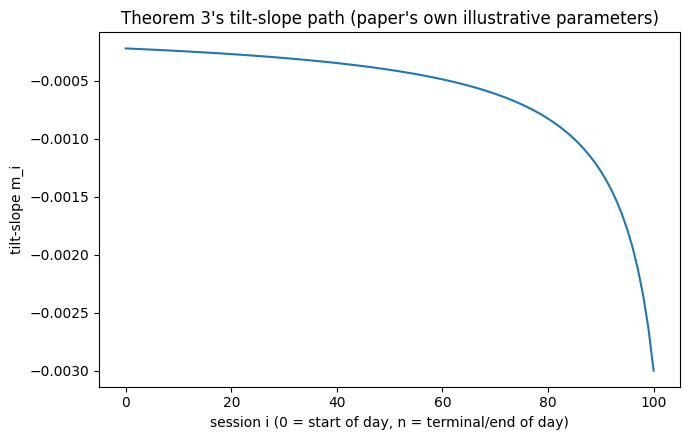

In [4]:
A, B_toy, C, D_toy = 40.0, 2000.0, 40.0, 200.0
S_toy, K_toy, sigma_toy, T_mat_toy = 100.0, 100.0, 0.01, 400.0
gamma_toy = 0.006
t0, tn, T_toy = 0.0, 1.0, 1.5
n_sessions_toy = 100
session_dt_toy = (tn - t0) / n_sessions_toy
terminal_horizon_toy = T_toy - tn

delta_toy = float(bs.delta(S_toy, K_toy, T_mat_toy, 0.0, 0.0, sigma_toy, 'C'))
stock_intensity_toy = quoting.LinearIntensity(C=A, D=B_toy)
option_intensity_toy = quoting.LinearIntensity(C=C, D=D_toy)

m_toy = quoting.compute_tilt_slope_path(
    n_sessions_toy, session_dt_toy, terminal_horizon_toy, gamma_toy, sigma_toy, S_toy, delta_toy,
    stock_intensity_toy, option_intensity_toy,
)
print(f"delta_toy = {delta_toy:.4f}")
print(f"m_n (terminal) = {m_toy[-1]:.6f}   m_0 (start of day) = {m_toy[0]:.6f}")
print(f"|m_0| / |m_n| = {abs(m_toy[0]) / abs(m_toy[-1]):.4f}  <-- now clearly visible, matching the paper's own m_n >> m_0 finding")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(n_sessions_toy + 1), m_toy)
ax.set_xlabel('session i (0 = start of day, n = terminal/end of day)')
ax.set_ylabel('tilt-slope m_i')
ax.set_title("Theorem 3's tilt-slope path (paper's own illustrative parameters)")
plt.tight_layout()

## 5. A numerical-stability caveat, found honestly

The recursion above is an explicit-Euler discretization of a Riccati-type equation. Trying the paper's *other* illustrative gamma (`gamma=0.1`, their "high risk aversion" example) with the same setup actually **diverges** -- the per-step correction overshoots past zero once `session_dt * coef * |m_next|` stops being small, and blows up. `compute_tilt_slope_path` now raises a clear `RuntimeError` rather than silently returning `inf`/garbage when that happens (see its docstring). Reproduced deliberately below to show the failure mode, not as something broken.

In [5]:
try:
    quoting.compute_tilt_slope_path(
        n_sessions_toy, session_dt_toy, terminal_horizon_toy, gamma=0.1, sigma_risk=sigma_toy,
        S=S_toy, delta=delta_toy, stock_intensity=stock_intensity_toy, option_intensity=option_intensity_toy,
    )
except RuntimeError as exc:
    print(f"raised as expected: {exc}")

# the fix that works: finer discretization (more, smaller sessions) over the same total horizon
m_toy_fine = quoting.compute_tilt_slope_path(
    n_sessions_toy * 50, session_dt_toy / 50, terminal_horizon_toy, gamma=0.1, sigma_risk=sigma_toy,
    S=S_toy, delta=delta_toy, stock_intensity=stock_intensity_toy, option_intensity=option_intensity_toy,
)
print(f"\nwith 50x finer sessions: m_n={m_toy_fine[-1]:.6f}  m_0={m_toy_fine[0]:.6f}  "
      f"|m_0|/|m_n|={abs(m_toy_fine[0]) / abs(m_toy_fine[-1]):.4f}")

raised as expected: tilt-slope recursion diverged at session 99 (m=np.float64(0.05291414093899198)): the explicit backward recursion is only numerically stable while session_dt*coef*|m_next| stays well below 1 each step -- use more/smaller sessions (larger n_sessions over the same total horizon) or a smaller gamma/terminal_horizon

with 50x finer sessions: m_n=-0.050000  m_0=-0.000241  |m_0|/|m_n|=0.0048


## 6. Validate: Theorem 3 collapses to Theorem 2 at `n_sessions=1`

Using the live-calibrated numbers from Sections 1-2 -- the paper's own claim, checked directly rather than taken on faith.

In [6]:
m_single = quoting.compute_tilt_slope_path(
    1, horizon, horizon, gamma, sigma_risk, S0, delta0, stock_bid_intensity, option_bid_intensity
)

q2 = quoting.quote_theorem2(S0, K0, T0, r, q, sigma0, 'C', stock_bid_intensity, option_bid_intensity,
                             gamma=gamma, sigma_risk=sigma_risk, horizon=horizon, q_s=3.0, q_o=20.0)
q3 = quoting.quote_theorem3(S0, K0, T0, r, q, sigma0, 'C', stock_bid_intensity, option_bid_intensity,
                             m_next=m_single[-1], q_s=3.0, q_o=20.0)

print(f"Theorem 2 stock bid/ask: {q2.bid_stock_premium:.6f} / {q2.ask_stock_premium:.6f}")
print(f"Theorem 3 stock bid/ask: {q3.bid_stock_premium:.6f} / {q3.ask_stock_premium:.6f}")
print(f"match: {np.isclose(q2.ask_stock_premium, q3.ask_stock_premium) and np.isclose(q2.bid_stock_premium, q3.bid_stock_premium)}")

Theorem 2 stock bid/ask: 1.862383 / 0.330203
Theorem 3 stock bid/ask: 1.862383 / 0.330203
match: True


## 7. Early vs. late session, using the toy example

Where the effect is actually visible: sweep `q_s` at the terminal session (`m_n`, using the toy path) vs. session 1 (`m_1`, near the start of the day) and compare the tilt slopes directly.

late-session swing over q_s in [-10,10]:  0.0200
early-session swing over q_s in [-10,10]: 0.0044


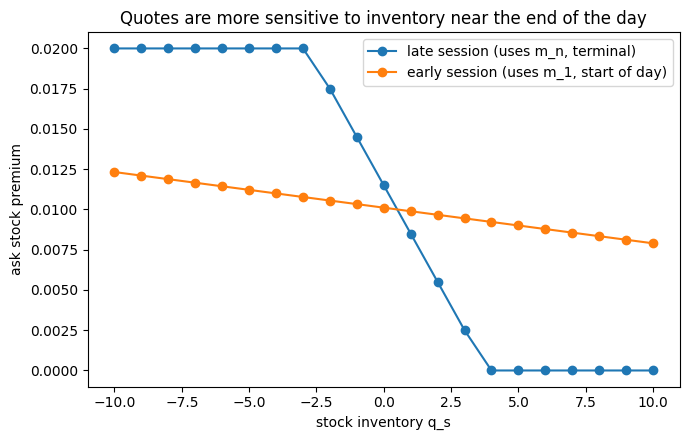

In [7]:
q_s_grid = np.linspace(-10, 10, 21)

def ask_stock_curve(m_next):
    return [
        quoting.quote_theorem3(S_toy, K_toy, T_mat_toy, 0.0, 0.0, sigma_toy, 'C',
                                stock_intensity_toy, option_intensity_toy, m_next=m_next, q_s=q_s, q_o=0.0).ask_stock_premium
        for q_s in q_s_grid
    ]

late_curve = ask_stock_curve(m_toy[-1])   # session n-1, using m_n
early_curve = ask_stock_curve(m_toy[1])   # session 0, using m_1

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(q_s_grid, late_curve, 'o-', label='late session (uses m_n, terminal)')
ax.plot(q_s_grid, early_curve, 'o-', label='early session (uses m_1, start of day)')
ax.set_xlabel('stock inventory q_s')
ax.set_ylabel('ask stock premium')
ax.set_title('Quotes are more sensitive to inventory near the end of the day')
ax.legend()
plt.tight_layout()

print(f"late-session swing over q_s in [-10,10]:  {late_curve[0] - late_curve[-1]:.4f}")
print(f"early-session swing over q_s in [-10,10]: {early_curve[0] - early_curve[-1]:.4f}")

## What this doesn't cover yet

- **State-dependent I_i/J_i:** `compute_tilt_slope_path` assumes the paper's auxiliary indicators (whether each session's own premiums are strictly inside their bounds) equal 2 at every step. The paper's exact recursion lets them depend on the realized inventory path, which needs a full backward induction over an inventory grid (their Appendix C, Lemma 6) -- not implemented here. This assumption holds away from extreme inventory and breaks down near it, same as every clipping-bound assumption elsewhere in this codebase.
- **Section IV (stochastic vol + jump risk, Theorems 4-5):** still open -- needs a *history* of fitted surfaces to estimate vol-of-implied-vol, not a single snapshot.
- **A real inventory tracker:** `q_s`/`q_o` are still swept as parameters, not persisted across sessions -- nothing here actually simulates a day of fills and evolving inventory through the recursion.
- **Numerical stability:** the explicit backward recursion can diverge for large risk aversion / large session steps (Section 5) -- an implicit or smaller-step scheme would be more robust but wasn't needed for the cases this notebook actually uses.

The main finding worth carrying forward: **at today's real Deribit BTC liquidity, Theorem 2's one-period solution already captures the interesting economics** -- the multi-period correction only matters at toy/illustrative liquidity scales, or over timescales far beyond any realistic re-quoting cadence.